YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Data columns: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


C:\Users\T H I N K P A D\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0234
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 3.6567e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3.2805e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 2.9593e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 2.7794e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 3.0964e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 2.8705e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 2.9697e-04
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.2996e-04
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 2.5531e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Mean Absolute Error (MAE): 4.532754374816355
Root Mean Squared Error (RMSE): 5.4153736441889455


C:\Users\T H I N K P A D\AppData\Local\Temp\ipykernel_3348\2614506472.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


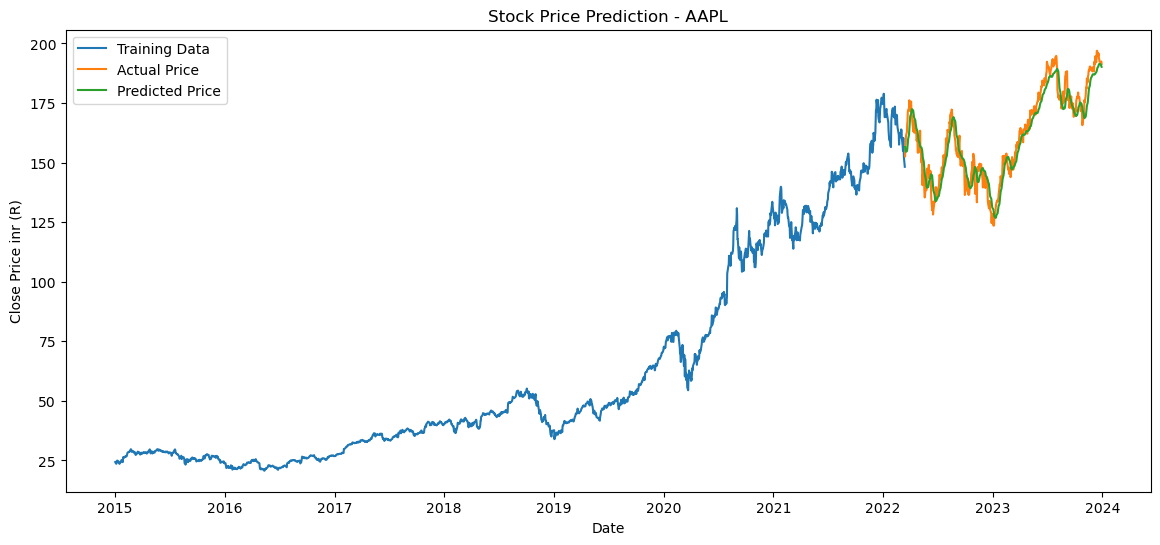

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')


print("Data columns:", df.columns)


data = df[['Close']].copy()  
dataset = data.values  
training_data_len = int(np.ceil(len(dataset) * 0.8))  


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)


sequence_length = 60
train_data = scaled_data[0:training_data_len, :]

X_train = []
y_train = []

for i in range(sequence_length, len(train_data)):
    X_train.append(train_data[i-sequence_length:i, 0])
    y_train.append(train_data[i, 0])


X_train, y_train = np.array(X_train), np.array(y_train)


X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

#  LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))


model.compile(optimizer='adam', loss='mean_squared_error')


model.fit(X_train, y_train, batch_size=32, epochs=10)


test_data = scaled_data[training_data_len - sequence_length:, :]
X_test = []
y_test = dataset[training_data_len:, :]  

for i in range(sequence_length, len(test_data)):
    X_test.append(test_data[i-sequence_length:i, 0])


X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  


mae = mean_absolute_error(y_test, predictions)
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(14, 6))
plt.title('Stock Price Prediction - AAPL')
plt.xlabel('Date')
plt.ylabel('Close Price inr (R)')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend()
plt.show()


In [2]:
pip install yfinance


     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.2 MB/s eta 0:00:02
     ------------- -------------------------- 1.0/3.0 MB 415.9 kB/s eta 0:00:05
     ------------- -------------------------- 1.0/3.0 MB 415.9 kB/s eta 0:00:05
     ----


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip
